# Detección de Anomalías en Red — Explicación Completa

Este notebook contiene el **mismo código** del proyecto de detección de anomalías, pero con explicaciones detalladas junto a cada paso. Está escrito para que puedas seguirlo aunque sea tu primera vez con estos conceptos.

### ¿Qué problema estamos resolviendo?

Imagina que eres el guardia de seguridad de un edificio. Miles de personas entran y salen cada día. La mayoría son empleados normales, pero de vez en cuando alguien intenta entrar sin permiso. Tu trabajo es detectar a esos intrusos.

Ahora cambia "edificio" por **red de computadoras** y "personas" por **tráfico de datos**. Eso es exactamente lo que hace este proyecto:

- Observa el tráfico que entra y sale de una red.
- Aprende cómo se ve el tráfico **normal**.
- Detecta cuando algo se ve **diferente** (anómalo), lo que podría ser un ataque, una fuga de datos o un mal funcionamiento.

Para lograr esto, entrenamos una **red neuronal** que aprende a clasificar cada muestra de tráfico como `Normal` o `Anomalía`.

---
## Paso 1: Instalación de librerías

Antes de escribir código, necesitamos herramientas. Cada librería tiene un propósito:

- **pandas**: Para leer y manipular tablas de datos (como una hoja de Excel pero en código).
- **numpy**: Para operaciones matemáticas con números y arreglos.
- **seaborn / matplotlib**: Para crear gráficas y visualizaciones.
- **scikit-learn**: Herramientas de machine learning: dividir datos, escalarlos, medir resultados.
- **tensorflow**: La librería que nos permite construir y entrenar la red neuronal.

In [1]:
!pip install pandas numpy seaborn matplotlib scikit-learn tensorflow


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Ahora importamos todo lo que vamos a usar. Cada línea trae una herramienta específica.

`np.random.seed(42)` y `tf.random.set_seed(42)` fijan la "semilla aleatoria". Muchos procesos en machine learning usan números aleatorios (por ejemplo, los pesos iniciales de la red). Al fijar la semilla, nos aseguramos de que cada vez que ejecutemos el notebook obtengamos los mismos resultados. El número 42 no tiene nada de especial — es una convención (referencia a *The Hitchhiker's Guide to the Galaxy*).

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('ggplot')

---
## Paso 2: Cargar y explorar los datos

Nuestro dataset es un archivo CSV (valores separados por comas) con 1,654 muestras de tráfico de red. Cada fila es un momento en el tiempo donde se midió el tráfico, y las columnas son:

| Columna | ¿Qué mide? | Analogía simple |
|---------|-----------|----------------|
| **Inbound Rate (bit/s)** | Velocidad de datos que **entran** a la red | Cuánta agua entra por una tubería |
| **Outbound Rate (bit/s)** | Velocidad de datos que **salen** de la red | Cuánta agua sale por otra tubería |
| **Inbound Bandwidth Utilization (%)** | Qué porcentaje de la capacidad de entrada se está usando | Qué tan llena está la tubería de entrada |
| **Outbound Bandwidth Utilization (%)** | Qué porcentaje de la capacidad de salida se está usando | Qué tan llena está la tubería de salida |
| **Estado_Trafico** | La respuesta correcta: 0 = normal, 1 = anomalía | La etiqueta que dice si hubo problema o no |

Renombramos la columna original `Label` a `Estado_Trafico` porque "Label" es genérico y no dice nada sobre lo que clasifica. `Estado_Trafico` deja claro que estamos clasificando el **estado** del tráfico de red.

In [3]:
df = pd.read_csv("data/networkanomalydataset.csv")
df.rename(columns={'Label': 'Estado_Trafico'}, inplace=True)
df.head(5)

,Inbound Rate(bit/s),Outbound Rate(bit/s),Inbound Bandwidth Utilization(%),Outbound Bandwidth Utilization(%),Estado_Trafico
0,0.931000,1.224246,0.931001,1.224244,0
1,0.965773,1.302733,0.965944,1.303585,0
2,1.018103,1.341763,1.017932,1.342183,0
3,1.088629,1.374144,1.088671,1.374348,0
4,1.128772,1.381435,1.128727,1.380781,0


### Verificar datos faltantes

Antes de hacer cualquier cosa, revisamos si hay valores que falten (nulos). En una tabla de tráfico de red, un valor faltante podría significar que el sensor de monitoreo falló o que se perdieron paquetes durante la captura.

Si hubiera nulos, tendríamos que decidir: ¿los rellenamos con algún valor estimado? ¿o eliminamos esas filas? Cada opción tiene consecuencias. Pero en nuestro caso no hay ninguno, así que podemos avanzar tranquilos.

In [4]:
df.isnull().sum()

Inbound Rate(bit/s)                  0
Outbound Rate(bit/s)                 0
Inbound Bandwidth Utilization(%)     0
Outbound Bandwidth Utilization(%)    0
Estado_Trafico                       0
dtype: int64

---
## Paso 3: Análisis Exploratorio de Datos (EDA)

Es como cuando un doctor te revisa antes de recetarte algo. No tendría sentido darte medicina sin saber qué tienes. Con los datos pasa igual: antes de construir el modelo, necesitamos entender qué tenemos.

### Distribución de clases

Lo primero es contar cuántas muestras hay de cada tipo. Si una clase tuviera muchas más muestras que la otra, el modelo podría "hacer trampa" — por ejemplo, si el 99% fueran normales, podría decir siempre "normal" y acertar el 99% sin aprender nada. Nuestro dataset está **perfectamente balanceado** (827 y 827), así que no hay ese problema.

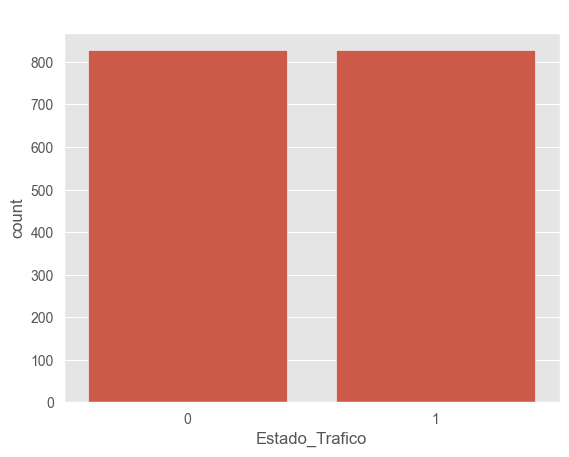

In [5]:
sns.countplot(x="Estado_Trafico", data=df)
plt.title('Distribución de Clases (0: Normal, 1: Anomalía)')
plt.show()

### Mapa de correlación

La **correlación** mide qué tanto se mueven dos variables juntas. Si cuando una sube la otra también sube, están altamente correlacionadas.

En el mapa de calor, los colores más rojos o azules intensos indican alta correlación. Verás que Inbound Rate e Inbound Bandwidth Utilization son casi idénticas (miden cosas muy parecidas). Lo mismo con las de Outbound. Esto quiere decir que aunque tenemos 4 columnas, en realidad la información útil se reduce a unas 2 dimensiones. Esto hará que el problema sea más fácil para el modelo.

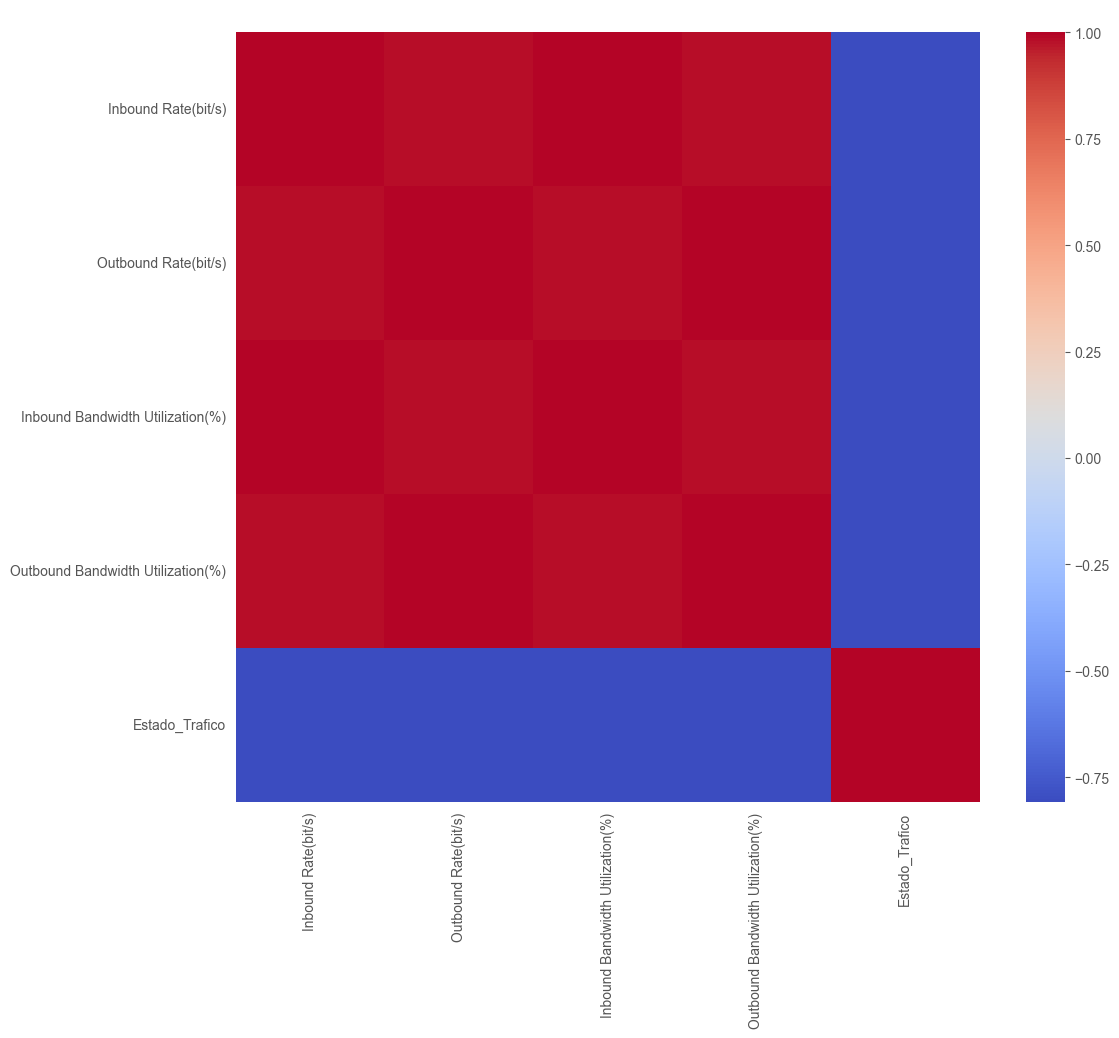

In [6]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Mapa de Correlación entre Características')
plt.show()

### Pairplot: relación entre variables de entrada y salida

Este gráfico muestra cómo se relacionan la tasa de entrada y la tasa de salida, coloreando cada punto según su clase. Si los colores se separan claramente en zonas distintas, es buena señal: significa que las variables SÍ contienen información útil para distinguir normal de anomalía.

Tomamos una muestra de 500 puntos para que la gráfica sea legible.

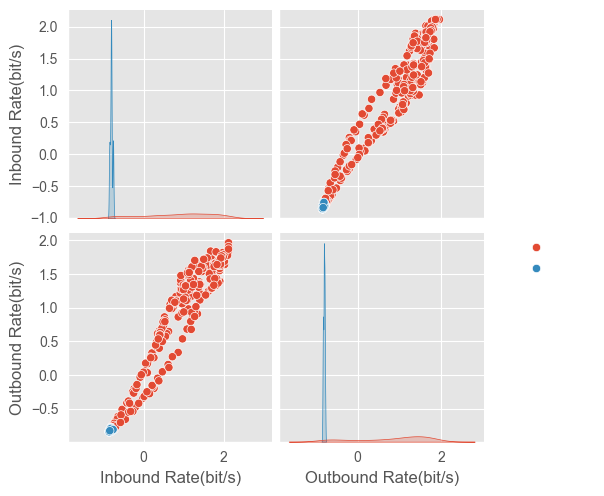

In [7]:
sampled_df = df.sample(min(500, len(df)))
sns.pairplot(sampled_df[['Inbound Rate(bit/s)', 'Outbound Rate(bit/s)', 'Estado_Trafico']], hue='Estado_Trafico')
plt.show()

### Boxplots: detección de valores extremos (outliers)

Un **boxplot** (diagrama de caja) muestra la distribución de cada variable. La caja central contiene el 50% de los datos, y los puntos fuera de los "bigotes" son **outliers** — valores inusualmente altos o bajos.

Aquí los separamos por clase (normal vs anomalía) para ver si las distribuciones son diferentes. Si las cajas de ambas clases están en zonas distintas, es otra confirmación de que el modelo tendrá con qué trabajar.

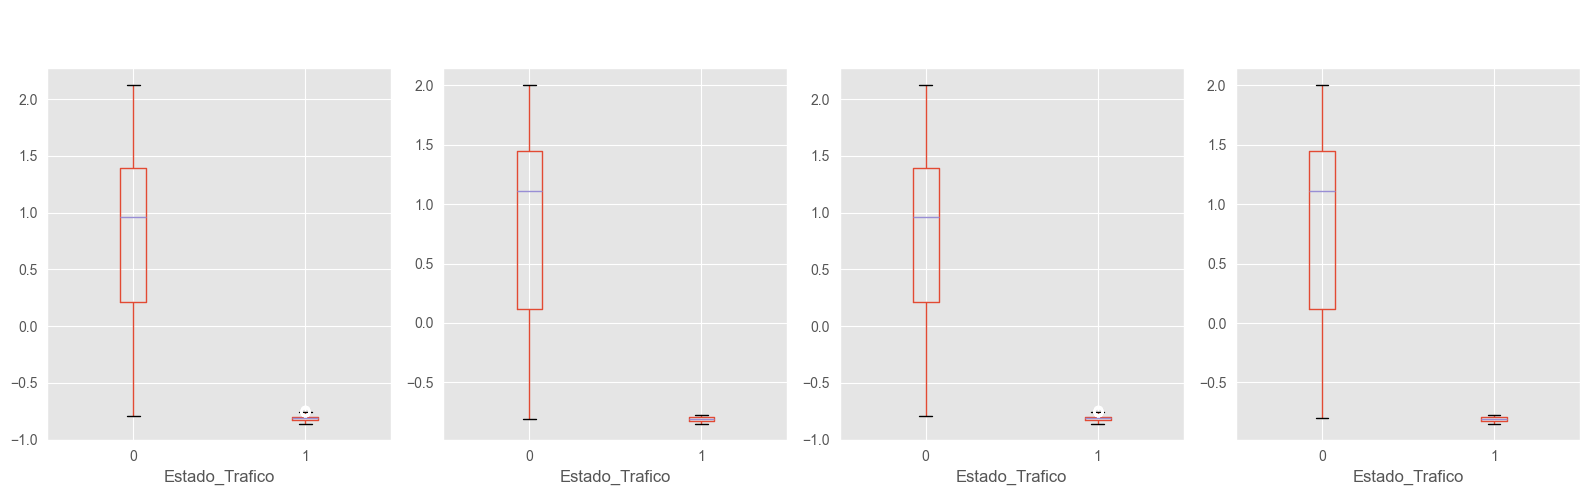

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, df.columns):
    if col != 'Estado_Trafico':
        df.boxplot(column=col, by='Estado_Trafico', ax=ax)
        ax.set_title(col[:20])
plt.suptitle('Distribución de características por clase')
plt.tight_layout()
plt.show()

---
## Paso 4: Preprocesamiento de datos

Los datos crudos no se pueden meter directamente al modelo. Necesitan preparación.

### 4.1 Dividir en entrenamiento y prueba

Separamos los datos en dos grupos:
- **70% para entrenar** (~1,157 muestras): el modelo aprende de estos.
- **30% para probar** (~497 muestras): datos que el modelo **nunca ve** durante el entrenamiento.

Piensa en un examen escolar. Si el maestro te da las respuestas de antemano y luego te hace el mismo examen, sacarías 100... pero no aprendiste nada. El conjunto de prueba es como un examen sorpresa: mide si realmente entendió los patrones o solo memorizó.

¿Por qué 70/30? Con solo 1,654 muestras, necesitamos un grupo de prueba grande (~497) para que los resultados sean confiables. Con 90/10 solo tendríamos ~165 y cualquier error individual afectaría mucho las métricas.

`stratify=y` asegura que ambos grupos mantengan la misma proporción de clases (50/50). Sin esto, podría pasar que por azar un grupo tenga más normales que anomalías.

In [9]:
X = df.drop('Estado_Trafico', axis=1)
y = df['Estado_Trafico']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### 4.2 Estandarización con StandardScaler

Este paso transforma cada variable para que tenga **media 0** y **desviación estándar 1**.

Imagina que tienes dos variables: una mide temperatura (valores entre 20 y 40) y otra mide presión (valores entre 980 y 1020). Aunque ambas sean igual de importantes, la presión tiene números más grandes. Sin estandarizar, el modelo le daría más "atención" a la presión simplemente por su magnitud, no por su importancia.

StandardScaler pone todas las variables en la misma escala para que el modelo juzgue cada una por su contenido informativo.

**¿Por qué StandardScaler y no MinMaxScaler?** MinMaxScaler comprime los valores entre 0 y 1, pero es muy sensible a outliers: un solo valor extremo distorsiona toda la escala. StandardScaler es más robusto y funciona mejor con ReLU (la función de activación que usamos, que explicaremos más adelante).

**Detalle clave:** Hacemos `fit_transform` solo en el entrenamiento y `transform` en la prueba. Calculamos la media y desviación SOLO con datos de entrenamiento. Si usáramos todos los datos, estaríamos "filtrando" información del conjunto de prueba al entrenamiento. Esto se llama **data leakage** y hace que las métricas sean engañosamente buenas.

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

---
## Paso 5: Construir la red neuronal

Aquí es donde todo se junta. Vamos a explicar cada pieza del modelo en profundidad.

### ¿Qué es una red neuronal?

Es un programa que **aprende patrones a partir de ejemplos**, en lugar de seguir reglas que un programador escribió a mano.

Funciona vagamente inspirada en el cerebro:
- Tiene **neuronas** (unidades de cálculo) organizadas en **capas**.
- Cada neurona recibe números, hace un cálculo y pasa el resultado a la siguiente capa.
- Las conexiones entre neuronas tienen **pesos** (números que determinan la fuerza de cada conexión).
- Durante el entrenamiento, la red **ajusta esos pesos** para que sus predicciones se acerquen a las respuestas correctas.

Es como aprender a cocinar: al principio echas sal sin saber cuánta poner (pesos aleatorios), pruebas el resultado (comparas con la respuesta correcta), y ajustas la cantidad la próxima vez (actualizas los pesos). Después de muchas repeticiones, aprendes la cantidad justa.

---

### ¿Por qué una red neuronal y no otro modelo?

Existen muchos algoritmos de machine learning. Cada uno tiene ventajas, pero elegimos red neuronal por razones concretas:

**Regresión Logística** traza una línea recta para separar las clases. Pero el tráfico de red puede tener patrones más complejos que una línea no captura. Por ejemplo: entrada alta con salida alta puede ser normal (descarga grande), pero entrada alta con salida MUY baja puede ser un ataque. Esa relación no es una línea recta.

**Random Forest** crea muchos "árboles de decisión" (como diagramas de flujo con preguntas sí/no). Es robusto, pero nuestras 4 variables están muy correlacionadas (Inbound Rate e Inbound Utilization miden casi lo mismo). Random Forest trata cada variable como independiente, duplicando información sin saberlo. La red neuronal, al combinar todas las variables en cada neurona, maneja esta correlación naturalmente.

**SVM** busca la frontera óptima entre clases. Podría funcionar, pero no escala bien si el dataset crece y no produce probabilidades de forma nativa (solo dice "normal" o "anomalía", no "78% seguro de anomalía"). En seguridad, esa probabilidad es muy útil.

**KNN** clasifica buscando las muestras más parecidas. Es lento en predicción y necesita guardar todo el dataset en memoria. En un sistema de monitoreo en tiempo real, esa lentitud es un problema.

---

### ¿Por qué una red *densa* y no otro tipo de red neuronal?

"Red neuronal" es un término amplio. Hay muchos tipos. La nuestra es una **red densa** (también llamada MLP o Fully Connected). Veamos por qué:

**Red Convolucional (CNN)** está diseñada para datos con **estructura espacial**, como imágenes. En una foto, los pixeles vecinos están relacionados (el pixel de la izquierda de tu nariz probablemente es parte de tu cara). Pero nuestras 4 variables no tienen "vecindad": no hay razón para creer que Inbound Rate sea "vecino" de Outbound Rate de una forma que un filtro espacial pueda explotar. Usar CNN aquí sería como intentar leer un número de teléfono con un detector de rostros.

**Red Recurrente (RNN / LSTM)** está diseñada para **secuencias** donde el orden importa: texto, audio, series de tiempo. Tienen "memoria" de lo que vieron antes. En nuestro dataset, cada fila es una **observación independiente** — no hay relación entre la fila 1 y la fila 2. Si tuviéramos datos como "los últimos 60 segundos de tráfico segundo a segundo", ahí sí tendría sentido una LSTM.

**Transformer** son las redes detrás de ChatGPT. Están diseñadas para secuencias largas con cientos o miles de elementos. Usarlas para 4 números sería como alquilar un avión para ir a la tienda de la esquina. Además, tendría más parámetros que muestras, garantizando sobreajuste.

**Autoencoder** se usa para detectar anomalías cuando **no tienes etiquetas** — aprende cómo se ve lo normal y marca como anómalo lo que no puede reconstruir. Pero nosotros **sí tenemos etiquetas** (sabemos cuáles son normales y cuáles anómalas). Usar un autoencoder sería desperdiciar esa información.

**La red densa funciona porque:**
1. Cada neurona ve **todas** las variables a la vez. Puede descubrir combinaciones como "entrada alta + utilización de salida baja = posible problema".
2. No asume estructura que no existe (no busca vecindades ni dependencias temporales).
3. Con solo 4 entradas, tiene ~3,300 parámetros: suficiente para el problema, pequeña para no sobreajustar.

---

### La arquitectura: capa por capa

```
4 entradas → 64 neuronas (ReLU) → Dropout 20% → 32 neuronas (ReLU) → 16 neuronas (ReLU) → 1 neurona (Sigmoid)
```

**Capa 1 (64 neuronas):** Cada neurona recibe los 4 valores, los multiplica por sus pesos, suma, y aplica ReLU. Son 64 "detectores" buscando cada uno un patrón diferente.

**Dropout (0.2):** Durante el entrenamiento, el 20% de las neuronas se desactivan al azar. Es como un equipo donde no dejas que todos dependan de la misma persona estrella. Si esa persona falta, todo se cae. Dropout fuerza a que el conocimiento se distribuya. El resultado es un modelo más robusto.

**Capas 2 y 3 (32 → 16 neuronas):** Las capas van reduciendo neuronas. Esto obliga a la red a **comprimir** la información. La de 64 captura muchos patrones; la de 32 los combina en conceptos más generales; la de 16 los sintetiza para la decisión final. Es como resumir un libro: primero anotas todos los detalles, luego resumes por capítulos, y finalmente haces un resumen de una página.

**¿Cuántas capas necesitamos realmente?** Probablemente bastarían 1 o 2. Con solo 4 variables (efectivamente ~2 dimensiones de información real), el problema es relativamente simple. Existe un teorema matemático (el **Teorema de Aproximación Universal**) que dice que una sola capa oculta con suficientes neuronas puede resolver cualquier problema. Mantenemos 3 como margen de seguridad conservador — el costo extra es mínimo y en seguridad informática preferimos un modelo con margen a uno que falle ante un patrón inesperado.

**Salida (1 neurona con Sigmoid):** Produce un número entre 0 y 1 — la probabilidad de anomalía. Si es mayor a 0.5, decimos "anomalía"; si es menor, "normal".

---

### Funciones de activación: por qué ReLU y Sigmoid

Las funciones de activación son el ingrediente que permite a la red aprender patrones complejos. Cada neurona hace este cálculo:

```
resultado = activación(peso1 × entrada1 + peso2 × entrada2 + ... + sesgo)
```

La parte de "peso × entrada + sesgo" es una operación **lineal** (una línea recta). Si solo tuviéramos eso, apilar 100 capas sería equivalente a tener 1 sola capa, porque combinar líneas rectas sigue dando una línea recta. La función de activación **rompe esa linealidad** y permite que la red aprenda curvas y fronteras complejas.

#### ReLU en las capas ocultas

ReLU (Rectified Linear Unit) es casi absurdamente simple: `ReLU(x) = máximo entre 0 y x`. Si el número es positivo, lo deja pasar. Si es negativo, lo convierte en 0.

¿Por qué algo tan simple funciona tan bien?

1. **Resuelve el gradiente evanescente.** Durante el entrenamiento, la red ajusta sus pesos usando una señal llamada **gradiente** que viaja desde la última capa hacia la primera, como un eco rebotando. Con funciones antiguas como Sigmoid en capas ocultas, esa señal se debilitaba en cada capa que atravesaba. En 3 capas, la señal que llegaba a la primera era tan débil que prácticamente dejaba de aprender. Con ReLU, la señal pasa sin debilitarse (gradiente = 1 para valores positivos).

2. **Es rapidísima.** Comparar un número con 0 es una de las operaciones más rápidas que puede hacer una computadora. Sigmoid y Tanh necesitan calcular exponenciales, mucho más costosas.

3. **Crea representaciones dispersas.** ReLU "apaga" neuronas que reciben valores negativos (salida = 0). Para cada muestra, solo parte de las neuronas están activas. Es como si la red seleccionara automáticamente qué detectores son relevantes para cada tipo de tráfico.

**¿Por qué no Sigmoid o Tanh en capas ocultas?** Ambas comprimen valores a un rango pequeño. En los extremos, el gradiente se vuelve casi 0 ("gradiente evanescente"). Con 3 capas, la señal de aprendizaje se reduce a prácticamente nada.

**¿Por qué no Leaky ReLU?** Es una variante que en vez de poner 0 para negativos, pone un valor muy pequeño (0.01 × x). Resuelve el problema de "neuronas muertas", pero con nuestros datos estandarizados (centrados en 0), ese problema casi no ocurre.

#### Sigmoid en la capa de salida

La misma Sigmoid que descartamos para capas ocultas es **perfecta** en la salida. Toma cualquier número y lo comprime al rango (0, 1). Eso es exactamente lo que necesitamos: una **probabilidad**.

Aquí no importa el gradiente evanescente porque es la última capa — no hay capas después que necesiten la señal.

**¿Por qué no Softmax?** Es para cuando tienes 3 o más clases. Con solo 2, se simplifica a Sigmoid. Usarla requeriría 2 neuronas de salida en lugar de 1, sin beneficio.

---

### El optimizador Adam y la función de pérdida

**Binary Crossentropy** es la función de pérdida (loss). Mide qué tan lejos estuvieron las predicciones de las respuestas correctas. Si la respuesta es 1 (anomalía) y el modelo predijo 0.99, el error es casi 0. Si predijo 0.01, el error es enorme.

El **optimizador** toma ese error y decide cuánto y en qué dirección ajustar cada peso. Es como estar en una montaña con niebla intentando llegar al valle más bajo: no ves el valle, pero sientes la pendiente bajo tus pies y caminas cuesta abajo. Ese "sentir la pendiente" se llama **gradiente**.

**¿Por qué Adam y no un descenso del gradiente simple (SGD)?**

SGD camina a la misma velocidad siempre. Si la velocidad (llamada **learning rate**) es muy alta, pasa de largo el valle. Si es muy baja, tarda cientos de pasos. Y tienes que elegir esa velocidad tú.

Adam adapta la velocidad automáticamente para cada peso individual, combinando dos ideas:

1. **Momentum (impulso):** Recuerda la dirección en la que venía caminando. Si ha estado bajando consistentemente hacia la izquierda, le da un empujón extra en esa dirección, como una bola rodando que gana velocidad. Cruza pequeños baches sin quedarse atascado.

2. **Tasa adaptativa:** Si la pendiente es pronunciada, reduce la velocidad para no pasarse. Si es suave, la aumenta. Cada peso tiene su propia velocidad.

Adam funciona bien con sus valores por defecto (`learning rate=0.001`). No necesitamos buscar la velocidad correcta. Con un dataset pequeño, eso es una gran ventaja.

**¿Por qué no RMSprop?** Tiene tasa adaptativa pero no momentum. Adam = RMSprop + Momentum.

**¿Por qué no Adagrad?** Su velocidad decae continuamente hasta que el modelo deja de aprender.

In [11]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

 Non-trainable params: 0 (0.00 B)

---
## Paso 6: Entrenar el modelo

Ahora la red va a aprender. Tres conceptos clave:

**Época:** Una pasada completa por todos los datos de entrenamiento. Es como releer un libro completo. Permitimos hasta 50 pasadas.

**Batch (lote):** En vez de ver las 1,157 muestras de golpe, las dividimos en grupos de 32. El modelo mira un grupo, ajusta pesos, mira el siguiente, ajusta otra vez. Actualizar más frecuentemente (cada 32 muestras) da más oportunidades de corregir errores. Además, la variabilidad entre batches introduce un "ruido" saludable que ayuda a escapar de soluciones mediocres.

**Early Stopping:** Un mecanismo de seguridad. Después de cada época medimos qué tan bien funciona con los datos de prueba. Si deja de mejorar por **5 épocas seguidas** (`patience=5`), detenemos el entrenamiento.

¿Para qué? Para evitar el **sobreajuste**. Hay un punto donde el modelo empieza a memorizar los datos de entrenamiento en lugar de aprender patrones generales. Más allá de ese punto, mejora en entrenamiento pero empeora en datos nuevos. Early Stopping detecta ese punto y para justo a tiempo.

`restore_best_weights=True` hace que el modelo vuelva a los pesos de la mejor época, no de la última. Es como guardar la partida justo antes de perder.

In [12]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9692 - loss: 0.0947 - val_accuracy: 0.9759 - val_loss: 0.0772


---
## Paso 7: Evaluar el modelo

Ahora probamos con las 497 muestras que el modelo nunca vio.

### ¿Por qué priorizamos Recall sobre Precision?

En ciberseguridad, **Recall es más importante**:

- Una **falsa alarma** (dice anomalía pero era normal) es molesta pero no peligrosa. Un analista la investiga, ve que no es nada, y sigue.
- Una **anomalía no detectada** (dice normal pero era un ataque) puede ser catastrófica. Un ataque pasa desapercibido, se roba información, se infecta la red.

Preferimos 10 falsas alarmas antes que dejar pasar 1 ataque real.

### Las métricas

**Precision:** De todas las veces que dijo "anomalía", ¿cuántas veces tenía razón? → 96%. De cada 100 alertas, 96 son reales.

**Recall:** De todas las anomalías reales, ¿cuántas detectó? → 100%. No se le escapó **ninguna**.

**F1-Score:** Promedio balanceado entre Precision y Recall. Ambas clases tienen 0.98 — rendimiento excelente.

**Accuracy:** 98% de aciertos general.

In [13]:
y_pred_proba = model.predict(X_test).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98       249
           1       0.95      1.00      0.98       248

    accuracy                           0.98       497
   macro avg       0.98      0.98      0.98       497
weighted avg       0.98      0.98      0.98       497



### Matriz de Confusión

Es una tabla 2×2 que muestra exactamente dónde acierta y dónde se equivoca:

```
                    PREDICCIÓN
                Normal    Anomalía
REAL  Normal  |  ~239   |   ~10    |  → falsas alarmas (molestas, no peligrosas)
      Anomalía|    0    |  ~248    |  → TODAS las anomalías detectadas
```

Lo más importante: la esquina inferior izquierda es **0**. Cero anomalías se escaparon.

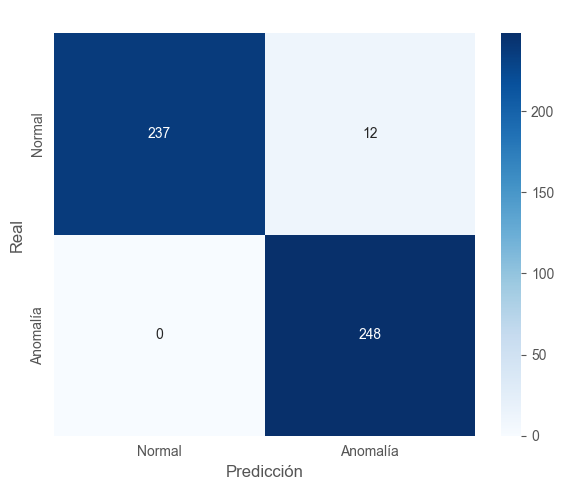

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomalía'],
            yticklabels=['Normal', 'Anomalía'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

### Curva de Pérdida (Loss)

Muestra cómo baja el error a lo largo de las épocas. Si las líneas de entrenamiento y validación bajan juntas y se estabilizan, el modelo aprendió bien. Si la de entrenamiento sigue bajando pero la de validación sube, hay **sobreajuste** (memoriza en lugar de aprender).

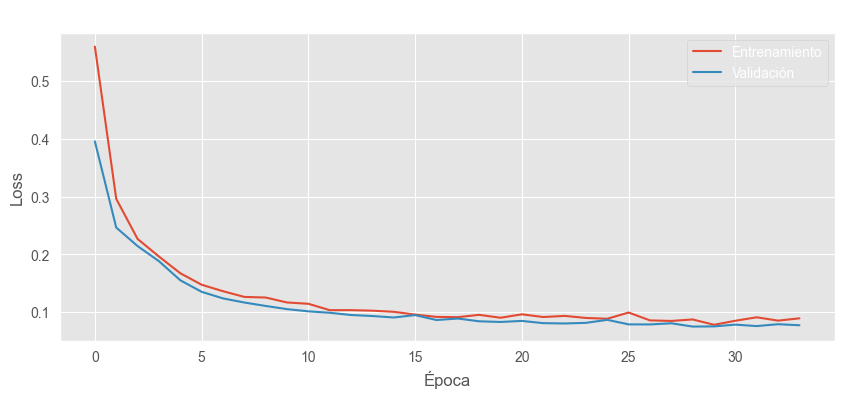

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Curva de Pérdida')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Curva de Accuracy

Muestra cómo sube la precisión. Ambas líneas deben subir y estabilizarse cerca. Si se separan mucho, el modelo funciona bien solo con datos que ya vio.

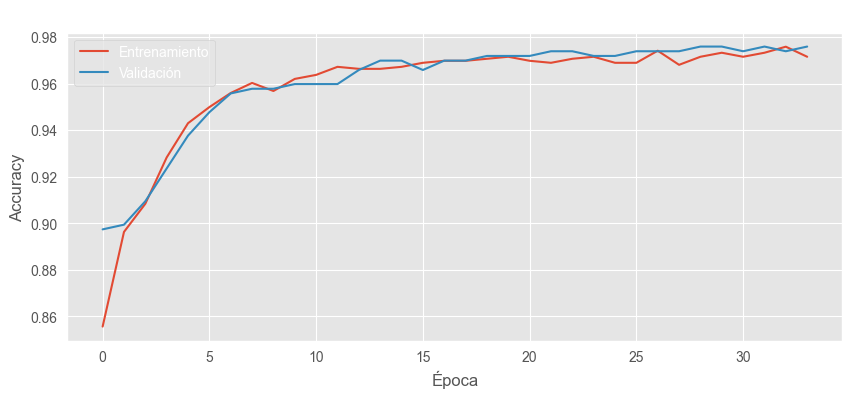

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Curva de Accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Curva ROC y AUC

La curva ROC muestra cómo cambia el rendimiento si movemos el umbral de decisión (en vez de 0.5, usar 0.3 o 0.7). El **AUC** (Area Under Curve) resume esto en un número:

- AUC = 1.0 → modelo perfecto
- AUC = 0.5 → modelo que adivina al azar (la línea punteada diagonal)

Nuestro AUC ≈ 0.98: sin importar el umbral que elijamos, el modelo mantiene buen rendimiento.

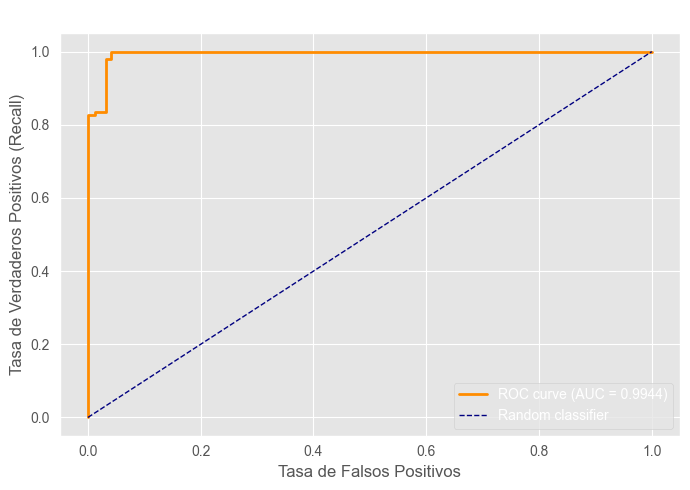

In [17]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random classifier')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## Resumen visual del pipeline completo

```
DATOS CRUDOS (CSV con 1,654 muestras)
    │
    ▼
EXPLORACIÓN (¿hay nulos? ¿están balanceados? ¿qué patrones hay?)
    │
    ▼
DIVIDIR en entrenamiento (70%) y prueba (30%)
    │
    ▼
ESTANDARIZAR (StandardScaler: media=0, desviación=1)
    │
    ▼
RED NEURONAL DENSA
    ┌─────────────────────────────────────────────┐
    │  4 entradas                                 │
    │      ↓                                      │
    │  64 neuronas (ReLU) → Dropout 20%           │
    │      ↓                                      │
    │  32 neuronas (ReLU)                         │
    │      ↓                                      │
    │  16 neuronas (ReLU)                         │
    │      ↓                                      │
    │  1 neurona (Sigmoid) → probabilidad 0 a 1   │
    └─────────────────────────────────────────────┘
    │
    ▼
ENTRENAMIENTO (Adam, Binary Crossentropy, EarlyStopping)
    │
    ▼
EVALUACIÓN (Accuracy 98%, Recall anomalías 100%, AUC ~0.98)
```

---
## Glosario de términos

| Término | Significado |
|---------|------------|
| **Accuracy** | Porcentaje de predicciones correctas sobre el total |
| **AUC** | Área bajo la curva ROC. Mide la capacidad de discriminación (1 = perfecto, 0.5 = azar) |
| **Batch** | Grupo de muestras que el modelo procesa antes de actualizar sus pesos |
| **Binary Crossentropy** | Función que mide el error en clasificación de 2 clases |
| **Data leakage** | Cuando información del conjunto de prueba se filtra al entrenamiento |
| **Dense (capa)** | Capa donde cada neurona se conecta a todas las neuronas de la capa anterior |
| **Dropout** | Desactiva neuronas al azar durante el entrenamiento para prevenir sobreajuste |
| **Early Stopping** | Detiene el entrenamiento cuando el modelo deja de mejorar |
| **Época** | Una pasada completa por todos los datos de entrenamiento |
| **Estandarización** | Transformar datos para que tengan media 0 y desviación estándar 1 |
| **F1-Score** | Promedio balanceado entre Precision y Recall |
| **Falso Negativo** | Anomalía real clasificada como normal (lo peor en seguridad) |
| **Falso Positivo** | Tráfico normal clasificado como anomalía (falsa alarma) |
| **Gradiente** | La pendiente del error. Indica en qué dirección ajustar cada peso |
| **Learning rate** | Tamaño de cada paso de ajuste. Muy alto = inestable, muy bajo = lento |
| **MLP** | Multi-Layer Perceptron. Otro nombre para red neuronal densa |
| **Neurona** | Unidad que multiplica entradas por pesos, suma, y aplica una activación |
| **Optimizador** | Algoritmo que decide cómo ajustar los pesos para reducir el error |
| **Overfitting** | Sobreajuste: el modelo memoriza en vez de aprender patrones generales |
| **Peso** | Número que determina la fuerza de una conexión. Se ajusta al entrenar |
| **Precision** | De las veces que predijo una clase, qué porcentaje acertó |
| **Recall** | De todas las muestras reales de una clase, qué porcentaje detectó |
| **ReLU** | Función de activación: deja pasar valores positivos, convierte negativos en 0 |
| **ROC** | Curva que muestra rendimiento en diferentes umbrales de decisión |
| **Sigmoid** | Función que comprime cualquier número al rango (0, 1) |
| **Stratify** | Dividir datos manteniendo la misma proporción de clases en cada grupo |